# Atelier Seaborn 

## Structure du projet 
### 4. Installer et importer seaborn, matplotlib, pandas, numpy

In [29]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as plt

print("Seaborn version :", sns.__version__)
print("Pandas version  :", pd.__version__)
print("NumPy version   :", np.__version__)


Seaborn version : 0.13.2
Pandas version  : 3.0.5
NumPy version   : 2.5.2


### 5. Importer mesures_capteurs.csv dans le dataframe df 

In [30]:
import pandas as pd

df = pd.read_csv("../data/mesures_capteurs.csv")


### 6. Vérifier le contenu du dataframe df 

In [31]:
# Vérification rapide du volume des données
print(f"Le tableau de données contient {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")
# Afficher les 5 premières lignes pour inspecter le contenu
df.head()

Le tableau de données contient 605 lignes et 9 colonnes.



,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 – Distribution d'une variable avec histplot() 
### 1) Afficher la distribution des températures 

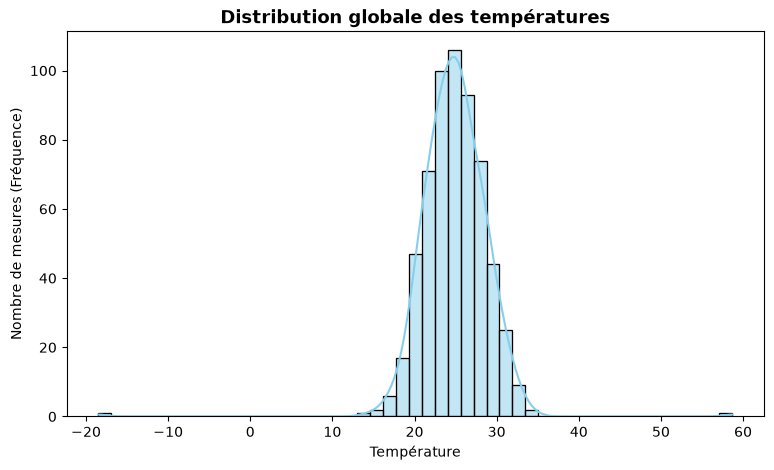

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5)) # Définit la taille du graphique en pouces (largeur=9, hauteur=5)
# On trace l'histogramme avec une estimation lissée de la densité (kde=True)
sns.histplot(data=df, x=df['temperature'], kde=True, color='skyblue')
# Personnalisation des titres et axes
plt.title("Distribution globale des températures", fontsize=13, fontweight='bold')
plt.xlabel("Température")
plt.ylabel("Nombre de mesures (Fréquence)")
plt.show()

### 2) Autour de quelle valeur les températures sont-elles concentrées ?

In [33]:
print(f"la moyenne est de : {df['temperature'].mean()}")
print(f"la mediane est de : {df['temperature'].median()}")


la moyenne est de : 24.87831385642738
la mediane est de : 24.86



En observant le sommet du pic de l'histogramme ci-dessus, on constate que la plus forte concentration des températures se situe autour de **25°C** (la moyenne calculée est de **24,88°C** et la valeur médiane est à **24,86°C**).

### 3) La distribution semble-t-elle symétrique ?

**Oui, elle semble symétrique**. La courbe (KDE) dessine une jolie forme en cloche , ce qui signifie que les températures s'écartent de manière équilibrée de part et d'autre de la moyenne centrale de 25°C.

### 4) Existe-t-il des valeurs extrêmes ?

**Oui, il y a de grosses valeurs extrêmes**. On constate une plage de valeurs normales entre 14°C et 35°C, mais on remarque de très rares points extrêmes isolés aux deux bords : des mesures négatives allant jusqu'à **-18°C** et une température très élevée atteignant **58°C**.

### 5) Modifier le nombre de classes (bins)

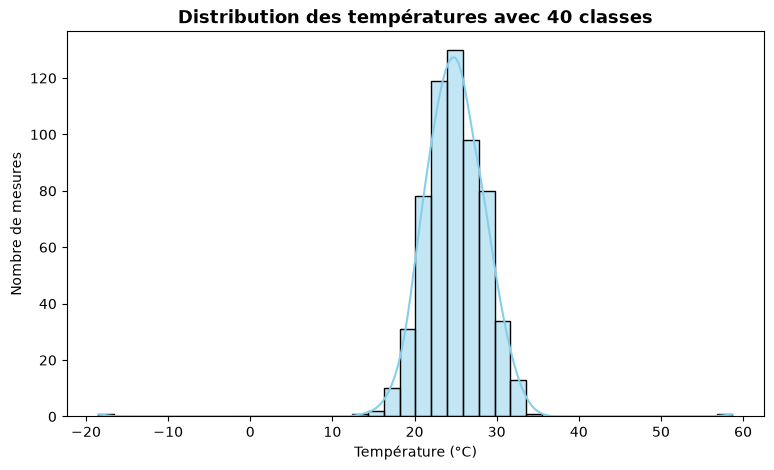

In [35]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='temperature', bins=40, kde=True, color='skyblue')
plt.title("Distribution des températures avec 40 classes", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

### 6) Afficher la distribution des températures par bâtiment

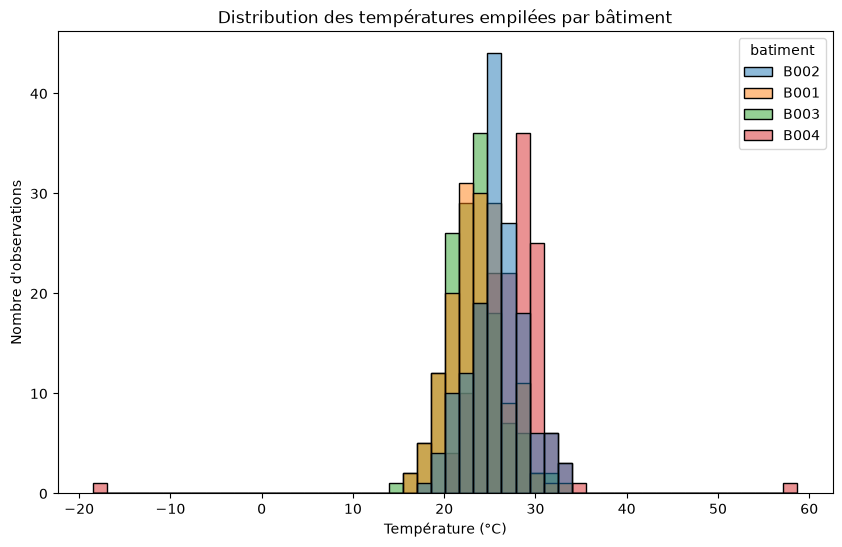

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='temperature', hue='batiment' ,bins=50)
plt.title("Distribution des températures empilées par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre d'observations")
plt.show()

## Partie 2 – Distribution d'une variable avec kdeplot() 
### 1) Afficher la distribution des températures 

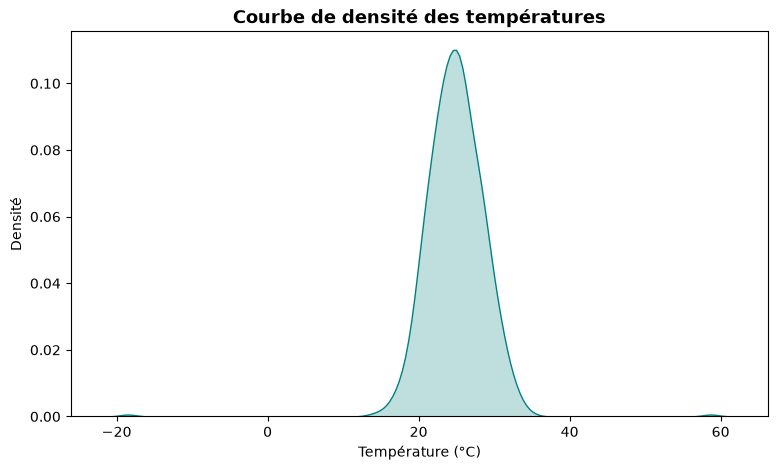

In [41]:
plt.figure(figsize=(9, 5))

# 'fill=True' permet d'ombrer l'aire sous la courbe pour un aspect professionnel
sns.kdeplot(data=df, x='temperature', fill=True, color='teal')
plt.title("Courbe de densité des températures", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

2) Afficher la distribution des températures par bâtiment 

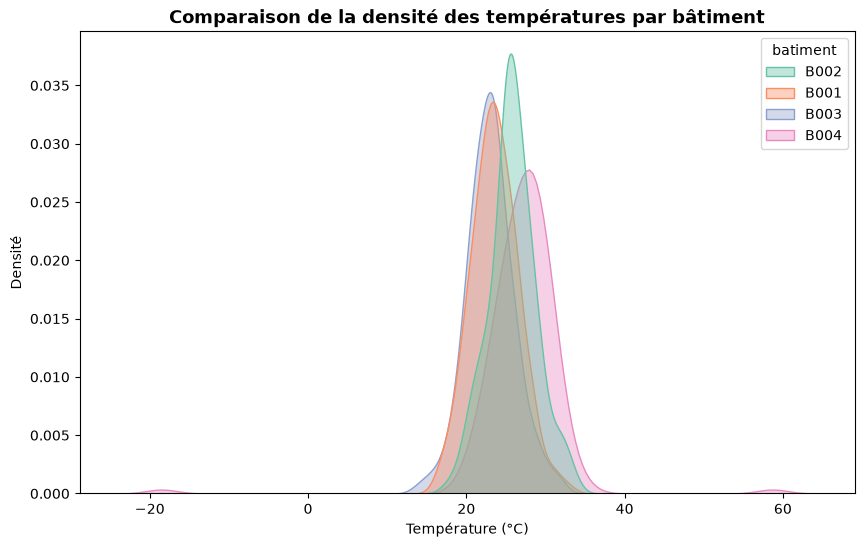

In [43]:
plt.figure(figsize=(10, 6))

# 'hue' crée une courbe de couleur par bâtiment
# 'alpha=0.4' ajoute de la transparence pour voir la superposition des différentes courbes
sns.kdeplot(data=df, x='temperature', hue='batiment', fill=True, palette='Set2', alpha=0.4)
plt.title("Comparaison de la densité des températures par bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()